In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, hour, month, to_timestamp

spark = SparkSession.builder.appName("AQI Full Analysis").getOrCreate()

df = spark.read.csv("INDIA_AQI_COMPLETE_20251126.csv", header=True, inferSchema=True)

# ---------------- CLEAN ----------------
df = df.withColumn("Datetime", to_timestamp(col("Datetime")))
df = df.dropna(subset=["US_AQI", "City"])

# ---------------- 1. TREND ----------------
# trend = df.groupBy("City", "Datetime").agg(avg("US_AQI").alias("AQI"))
# trend.limit(100000).toPandas().to_csv("trend.csv", index=False)

# ---------------- 2. HOURLY ----------------
df = df.withColumn("Hour", hour(col("Datetime")))
hourly = df.groupBy("Hour").agg(avg("US_AQI").alias("AQI"))
hourly.toPandas().to_csv("hourly.csv", index=False)

# ---------------- 3. CITY ----------------
city = df.groupBy("City").agg(avg("US_AQI").alias("AQI"))
city.toPandas().to_csv("city.csv", index=False)

# ---------------- 4. HEATMAP ----------------
df = df.withColumn("Month", month(col("Datetime")))
heatmap = df.groupBy("Month", "Hour").agg(avg("US_AQI").alias("AQI"))
heatmap.toPandas().to_csv("heatmap.csv", index=False)

# ---------------- 5. CORRELATION ----------------
corr_data = df.select(
    "US_AQI", "PM2_5_ugm3", "PM10_ugm3",
    "NO2_ugm3", "Temp_2m_C", "Humidity_Percent"
)
corr_data.limit(50000).toPandas().to_csv("corr.csv", index=False)

# ---------------- 6. MAP ----------------
map_data = df.select("City", "Latitude", "Longitude", "US_AQI")
map_data.limit(100000).toPandas().to_csv("map.csv", index=False)

print("✅ All Spark analytics files generated!")

✅ All Spark analytics files generated!


In [ ]:
# ---------------- 1. TREND ----------------
from pyspark.sql.functions import to_date

df = df.withColumn("Date", to_date(col("Datetime")))

trend = df.groupBy("City", "Date").agg(avg("US_AQI").alias("AQI"))

trend.toPandas().to_csv("trend.csv", index=False)


MORE ANALYTICS

In [ ]:
#window
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

window = Window.partitionBy("City").orderBy(col("US_AQI").desc())

ranked = df.withColumn("Rank", rank().over(window))

top_pollution = ranked.filter(col("Rank") <= 5)
top_pollution.show(10)
# top_pollution.toPandas().to_csv("top_events.csv", index=False)

import plotly.express as px

pdf = top_pollution.limit(100).toPandas()

fig = px.bar(
    pdf,
    x="City",
    y="US_AQI",
    color="US_AQI",
    title="Top Pollution Events by City",
    color_continuous_scale="Reds"
)

fig.show()

+---------+-------+--------+---------+-------------------+----+-----+---+----+-----------+--------+------------+----------+-------+------+-----------+---------+----------+-----------+-----------+----------------+-----------+-----------------+------------------+------------------+-------------------+------------+--------------+-------------+---------------+----------------+-------+----------+----------+----------------+--------------------+-------------------+--------------------+---------------------+--------+-------------------+-----------------+-----------------+------------------+----------+----------------+----------+---------+------------------+-------+--------+--------+-------+---------+--------+----+------+-----------+-----------+----------+---------+---------+------+-----------+-----------+--------------+-------------------+--------------+--------------------+---------------+-------------------+----------+----+
|     City|  State|Latitude|Longitude|           Datetime|Year|Mont

+-----+-----+--------+---------+-------------------+----+-----+---+----+-----------+--------+------------+----------+-------+------------+-----------+---------+----------+-----------+-----------+----------------+-----------+-----------------+------------------+------------------+-------------------+------------+--------------+-------------+---------------+----------------+-------+----------+----------+----------------+--------------------+-------------------+--------------------+---------------------+--------+-------------------+-----------------+-----------------+------------------+----------+----------------+----------+---------+------------------+-------+--------+--------+-------+---------+--------+----+------+-----------+-----------+----------+---------+---------+------+-----------+-----------+--------------+-------------------+--------------+--------------------+---------------+-------------------+----------+
| City|State|Latitude|Longitude|           Datetime|Year|Month|Day|Hour|

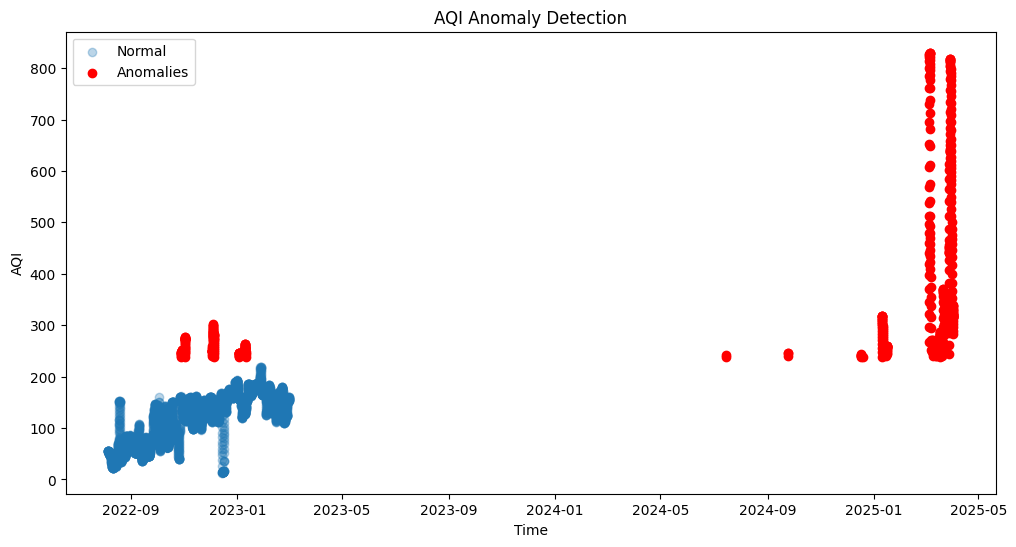

In [ ]:
#anomoly
from pyspark.sql.functions import mean, stddev

stats = df.select(
    mean("US_AQI").alias("mean"),
    stddev("US_AQI").alias("std")
).collect()[0]

threshold = stats["mean"] + 2 * stats["std"]

anomalies = df.filter(col("US_AQI") > threshold)
anomalies.show(10)
# anomalies.toPandas().to_csv("anomalies.csv", index=False)

import matplotlib.pyplot as plt

# Convert small sample to pandas
pdf = df.select("Datetime", "US_AQI").limit(5000).toPandas()
anom_pdf = anomalies.select("Datetime", "US_AQI").limit(500).toPandas()

plt.figure(figsize=(12,6))

# Normal data
plt.scatter(pdf["Datetime"], pdf["US_AQI"], alpha=0.3, label="Normal")

# Anomalies (highlighted)
plt.scatter(anom_pdf["Datetime"], anom_pdf["US_AQI"],
            color="red", label="Anomalies")

plt.xlabel("Time")
plt.ylabel("AQI")
plt.title("AQI Anomaly Detection")
plt.legend()

plt.show()

In [ ]:
# ---------------- CACHING ----------------
import time

print("🚀 Caching DataFrame...")

start = time.time()

df.cache()

# Trigger action (important!)
df.count()

end = time.time()

print(f"✅ Data cached successfully!")
print(f"⏱️ Time taken for first action (with caching): {round(end-start, 2)} seconds")

# ---------------- VERIFY CACHE ----------------
print("\n📊 Storage Level:")
print(df.storageLevel)

print("\n🔍 Number of Rows:")
print(df.count())

print("\n🧠 Schema:")
df.printSchema()

🚀 Caching DataFrame...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#FILTERING + CONDITIONAL ANALYSIS
high_pollution = df.filter(col("US_AQI") > 150)

city_high = high_pollution.groupBy("City").count()

# city_high.toPandas().to_csv("high_pollution_cities.csv", index=False)

city_high.show(10)

+-----------+-----+
|       City|count|
+-----------+-----+
|Bhubaneswar| 7035|
|   Agartala| 8439|
|    Gangtok|  639|
|    Chennai|  486|
|     Aizawl|  880|
|  Ahmedabad| 2415|
|   Gurugram|18539|
|   Dehradun| 1754|
|      Delhi|17313|
| Chandigarh| 6388|
+-----------+-----+
only showing top 10 rows


In [ ]:
#JOIN OPERATIONS
city_avg = df.groupBy("City").agg(avg("US_AQI").alias("Avg_AQI"))

joined = df.join(city_avg, on="City")

# joined.toPandas().to_csv("joined_data.csv", index=False)
city_avg.show(10)

+-----------+------------------+
|       City|           Avg_AQI|
+-----------+------------------+
|Bhubaneswar|103.73108317547788|
|   Agartala|105.52929223351128|
|    Gangtok| 65.99076976063371|
|    Chennai|  74.3470983296022|
|     Aizawl|59.562045806784916|
|  Ahmedabad| 89.11727225762012|
|   Gurugram|222.52168073015326|
|   Dehradun| 91.99280179094197|
|      Delhi|159.84363698983984|
| Chandigarh|115.33800585500258|
+-----------+------------------+
only showing top 10 rows
